
# 🧪 Lab 2 — Temperature & Diversity Mini-Experiment
*(Compare model outputs across temperatures)*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/labs/probability_lab.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

In this lab, you’ll explore how **temperature** affects the behavior of a large language model (LLM). You’ll design and run a small experiment to measure **diversity** in model outputs at different temperatures.

---



## 🎯 Learning Goals

By the end of this lab, you should be able to:

1. Explain what “temperature” means in probabilistic sampling.
2. Generate multiple model outputs with varying temperature.
3. Define and compute a simple **diversity metric**.
4. Compare how diversity changes as temperature increases.
5. Summarize your findings using the **scientific process**.


## 📚 Lecture Connection

**Before starting this lab, make sure you understand:**
- From **Week 2 Lecture**: What is temperature? (Lecture Day 2, Temperature section)
- From **Week 2 Lecture**: How does temperature affect the softmax distribution? (Lecture Day 2, Cell with softmax_temp function)
- From **Week 2 Lecture**: What is entropy and how does it relate to temperature? (Lecture Day 2, Entropy section)
- From **Week 2 Lecture**: How do prompts condition outputs? (Lecture Day 2, Prompt Patterns section)
- **New:** From **Week 2 Lecture**: How do prompt engineering patterns work with temperature? (Lecture Day 2, "Prompt Engineering + Temperature" section)

**This lab applies:**
- Understanding temperature's effect on sampling (Lecture Day 2, Temperature section)
- Measuring diversity as a proxy for entropy (Lecture Day 2, Entropy section)
- Connecting temperature to real-world use cases (Lecture Day 2, "When to Use Deterministic vs Stochastic" section)

**Key connection:** In the lecture, you learned that:
- Low temperature → more deterministic, factual outputs
- High temperature → more creative, diverse outputs
- Prompt engineering patterns (role-playing, few-shot, etc.) work together with temperature settings

In this lab, you'll **measure** this relationship by computing diversity at different temperatures.

If you need a refresher, review Lecture Week 2, especially Day 2 sections on Temperature, Entropy, and the new Prompt Engineering content.

---

## ✅ Before You Start Checklist

Before beginning this lab, make sure you can:
- [ ] Understand what a Python list is (e.g., `[0.3, 1.0, 2.0]`)
- [ ] Use a for loop in Python (e.g., `for item in list:`)
- [ ] Understand what a dictionary is in Python (e.g., `{"temperature": 0.3}`)
- [ ] Use matplotlib to create a simple plot (basic understanding)

**If you're unsure about any of these, review the Week 2 lecture first!**

---


In [1]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append("/content/main")
from course_utils import lab2_setup, lab2_generate_samples, lab2_measure_diversity, lab2_build_demo
from IPython.display import Markdown

lab2_setup()


🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab2_setup complete — helper function loaded.



## 🧩 Pre-Lab Questions

Answer in 1–2 sentences each:

1. In your own words, what does “temperature” control in an LLM?  
2. What do you predict will happen if we raise the temperature from 0.3 → 1.0 → 2.0?  
3. How would you define “diversity” in text outputs?  

> ✏️ *Edit this cell and write your answers below each question.*



## 🧭 Scientific Process

**Question:**  
If we increase temperature, how does the *diversity* of generated text outputs change?

**Hypothesis:**  
I expect that higher temperature will increase diversity (more varied wording or ideas) because the model will sample from lower-probability tokens more often.

**Experiment Plan:**  
1. Choose a single fixed prompt (e.g., “Describe a sunrise.”).  
2. Generate 5–10 outputs at each temperature (0.3, 1.0, 2.0).  
3. Record the results in a list or table.  
4. Compute a simple diversity metric for each temperature.  
5. Compare and visualize results.

**Measurement (Metric):**  
- **Diversity Index = (unique outputs) / (total outputs)**  

**Expected Shape:**  
Diversity should increase with temperature — low T gives similar outputs, high T gives more variety.



## 🔹 Part 1 — Generate Outputs Across Temperatures

We’ll use the helper function `lab2_generate_samples(prompt, temperatures, n_per_temp)`  
to collect model outputs across different temperatures.


In [6]:
prompt = "Describe a sunrise in one sentence."
temperatures = [0.3, 1.0, 2.0]

# TODO: Adjust number of samples per temperature (suggested: 5–10)
n_per_temp = 5

results = lab2_generate_samples(prompt, temperatures, n_per_temp)

# Display a few results
for r in results[:10]:
    display(f"T={r['temperature']}: {r['output']}")

🔄 Generating 15 responses...
  [1/15] Temperature 0.3, sample 1... ✅
  [2/15] Temperature 0.3, sample 2... ✅
  [3/15] Temperature 0.3, sample 3... ✅
  [4/15] Temperature 0.3, sample 4... ✅
  [5/15] Temperature 0.3, sample 5... ✅
  [6/15] Temperature 1.0, sample 1... ✅
  [7/15] Temperature 1.0, sample 2... ✅
  [8/15] Temperature 1.0, sample 3... ✅
  [9/15] Temperature 1.0, sample 4... ✅
  [10/15] Temperature 1.0, sample 5... ✅
  [11/15] Temperature 2.0, sample 1... ✅
  [12/15] Temperature 2.0, sample 2... ✅
  [13/15] Temperature 2.0, sample 3... ✅
  [14/15] Temperature 2.0, sample 4... ✅
  [15/15] Temperature 2.0, sample 5... ✅
✅ Generated 15 responses!


'T=0.3: The horizon blushes with hues of pink and gold as the sun slowly rises, casting a warm glow over the world and awakening the day.'

'T=0.3: The horizon blazes with hues of orange and pink as the sun slowly rises, casting a warm golden light that awakens the world from its slumber.'

'T=0.3: The horizon blushes with hues of orange and pink as the sun gently rises, casting a warm golden light that awakens the world from its slumber.'

'T=0.3: The horizon blushes with hues of pink and gold as the sun slowly rises, casting a warm glow that awakens the world from its slumber.'

...

'T=1.0: The horizon blazes to life as the sun rises, casting warm hues of orange and pink across the sky, gently awakening the world from its slumber.'

'T=1.0: The horizon blushes with hues of orange and pink as the sun peeks over the edge, casting a warm glow that awakens the world from the embrace of night.'

'T=1.0: The horizon blushes with hues of gold and pink as the sun gently crests, casting its warm glow over the awakening world.'

'T=1.0: The horizon ignites in a brilliant tapestry of oranges and pinks as the sun emerges, casting a warm glow over the waking world.'

'T=1.0: The sun peeks over the horizon, casting a warm golden glow that slowly transforms the sky into a breathtaking canvas of oranges, pinks, and soft purples.'


## 🔹 Part 2 — Measure Diversity

Now we’ll use `lab2_measure_diversity(results)` to compute a simple diversity score.


In [7]:
# Compute diversity metrics for your results
# This function groups outputs by temperature and calculates diversity for each group
diversity_scores = lab2_measure_diversity(results)

print("Diversity Scores by Temperature:")
print(diversity_scores)

# What do you notice?
# - Which temperature has the highest diversity?
# - Does this match what you expected from the lecture?
print("\n💭 Quick observation:")
max_temp = max(diversity_scores, key=diversity_scores.get)
print(f"Temperature {max_temp} produced the highest diversity ({diversity_scores[max_temp]:.2f})")

Diversity Scores by Temperature:
{0.3: 0.252, 1.0: 0.46, 2.0: 0.559}

💭 Quick observation:
Temperature 2.0 produced the highest diversity (0.56)



## 🔹 Part 3 — Visualize Results

Let’s visualize how diversity changes as temperature increases.


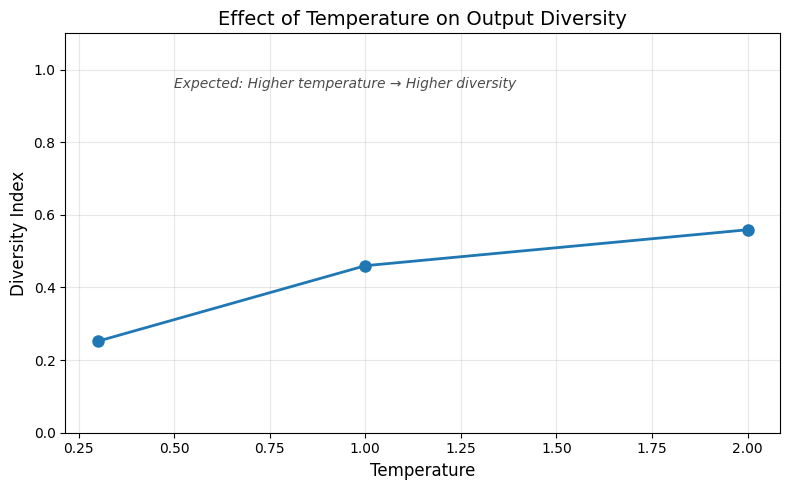

📊 Interpretation:
  - At T=0.3: Diversity = 0.25
  - At T=1.0: Diversity = 0.46
  - At T=2.0: Diversity = 0.56
  ✅ Diversity increases with temperature (matches hypothesis!)


In [8]:
import matplotlib.pyplot as plt

# Extract temperatures and their corresponding diversity scores
temps = list(diversity_scores.keys())
scores = list(diversity_scores.values())

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(temps, scores, marker='o', linewidth=2, markersize=8)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Diversity Index", fontsize=12)
plt.title("Effect of Temperature on Output Diversity", fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)  # Diversity is between 0 and 1

# Add a note about what we expect
plt.text(0.5, 0.95, "Expected: Higher temperature → Higher diversity",
         fontsize=10, style='italic', alpha=0.7)

plt.tight_layout()
plt.show()

# Print interpretation
print("📊 Interpretation:")
print(f"  - At T={temps[0]}: Diversity = {scores[0]:.2f}")
print(f"  - At T={temps[1]}: Diversity = {scores[1]:.2f}")
print(f"  - At T={temps[2]}: Diversity = {scores[2]:.2f}")
if scores[2] > scores[0]:
    print("  ✅ Diversity increases with temperature (matches hypothesis!)")
else:
    print("  ⚠️  Unexpected pattern - what might explain this?")

## Temperature + Prompt Engineering

**Connection to Lecture:** In the lecture, you learned about prompt engineering patterns (role-playing, few-shot, chain-of-thought). Let's see how these interact with temperature!

**Experiment:** Try the same prompt with different prompt engineering patterns at different temperatures.

**Example:**
- Basic prompt: "What is entropy?"
- With role: "You are a teacher. Explain entropy to a beginner."
- With structure: "What is entropy? Answer in 2 bullet points."

Try generating outputs for each at low (0.2) and high (1.0) temperature. What do you notice?


In [9]:
# @title Experiment with Prompt Engineering + Temperature
from openai import OpenAI
client = OpenAI()

# Try different prompt styles at different temperatures
question = "What is entropy?"

# Style 1: Basic prompt
basic_prompt = question

# Style 2: With role (from lecture Pattern 1)
role_prompt = f"You are a helpful teacher explaining concepts to beginners. {question}"

# Style 3: With structure (from lecture Pattern 4)
structure_prompt = f"{question} Answer in 2 bullet points."

# Generate at low temperature
print("=== LOW TEMPERATURE (T=0.2) ===\n")
for style_name, prompt in [("Basic", basic_prompt), ("With Role", role_prompt), ("With Structure", structure_prompt)]:
    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        temperature=0.2
    )
    print(f"{style_name}:")
    display(Markdown(response.output_text))
    print()

# Generate at high temperature
print("\n=== HIGH TEMPERATURE (T=1.0) ===\n")
for style_name, prompt in [("Basic", basic_prompt), ("With Role", role_prompt), ("With Structure", structure_prompt)]:
    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        temperature=1.0
    )
    print(f"{style_name}:")
    display(Markdown(response.output_text))
    print()

print("💭 What do you notice?")
print("  - Does temperature affect all prompt styles the same way?")
print("  - Which combination (style + temperature) gives the most consistent results?")
print("  - Which gives the most creative results?")


=== LOW TEMPERATURE (T=0.2) ===

Basic:


Entropy is a concept that appears in various fields, including thermodynamics, information theory, and statistical mechanics. Here are some key points about entropy in different contexts:

1. **Thermodynamics**: In this context, entropy is a measure of the disorder or randomness in a system. It quantifies the number of microscopic configurations that correspond to a thermodynamic system's macroscopic state. The second law of thermodynamics states that in an isolated system, entropy tends to increase over time, leading to a state of maximum disorder.

2. **Statistical Mechanics**: Entropy can be defined more rigorously using statistical mechanics, where it is related to the number of ways a system can be arranged at the microscopic level. Ludwig Boltzmann formulated the famous equation \( S = k \ln \Omega \), where \( S \) is entropy, \( k \) is Boltzmann's constant, and \( \Omega \) is the number of microstates corresponding to a macrostate.

3. **Information Theory**: In this field, entropy measures the uncertainty or unpredictability of information content. Claude Shannon introduced the concept of entropy in this context, defining it as a measure of the average amount of information produced by a stochastic source of data. The formula for Shannon entropy is \( H(X) = -\sum p(x) \log p(x) \), where \( p(x) \) is the probability of occurrence of each possible outcome \( x \).

4. **General Implications**: Entropy is often associated with the idea of irreversibility and the direction of processes in nature. For example, when a hot object cools down, the energy disperses, leading to an increase in entropy.

In summary, entropy is a fundamental concept that reflects the degree of disorder, uncertainty, or information in a system, and it has profound implications across various scientific disciplines.


With Role:


Entropy is a concept that comes from thermodynamics and information theory, and it can be understood in a few different ways depending on the context. Here’s a simple breakdown:

### In Thermodynamics:
1. **Definition**: Entropy is a measure of the disorder or randomness in a system. It helps us understand how energy is distributed in that system.
2. **Key Idea**: In a closed system, entropy tends to increase over time. This means that systems naturally progress from order to disorder. For example, if you have a box of gas molecules, over time, those molecules will spread out and fill the entire box rather than staying clustered in one corner.
3. **Second Law of Thermodynamics**: This law states that the total entropy of an isolated system can never decrease over time. It can only stay the same or increase, which is why processes like mixing and melting tend to happen spontaneously.

### In Information Theory:
1. **Definition**: Entropy measures the uncertainty or unpredictability of information content. It quantifies how much information is produced on average for each message received.
2. **Key Idea**: If you have a fair coin, the outcome (heads or tails) is uncertain, and thus it has high entropy. If you have a biased coin that always lands on heads, the outcome is predictable, and the entropy is low.

### Everyday Examples:
- **Thermodynamics**: Think of a messy room. Over time, without effort, it tends to get messier (higher entropy). Cleaning it up requires energy and effort (decreasing entropy).
- **Information Theory**: If you’re guessing a password, a longer and more complex password has higher entropy because it’s less predictable compared to a simple one.

### Summary:
Entropy is all about understanding disorder and uncertainty, whether in physical systems or in information. It helps explain why things change over time and how we can measure the unpredictability of different scenarios.


With Structure:


...


With Role:


Entropy is a concept that comes from thermodynamics and information theory, and it can be understood in a few different contexts. Here's a simple explanation:

1. **Thermodynamics**: In this context, entropy is a measure of the disorder or randomness in a system. When a system is highly ordered (like ice in a solid structure), it has low entropy. As it becomes more disordered (like when ice melts into water), the entropy increases. In general, the second law of thermodynamics states that the total entropy of an isolated system can never decrease over time; it tends to increase. This is often associated with the idea that systems evolve toward disorder.

2. **Information Theory**: Here, entropy measures the uncertainty or unpredictability of information. If you have a fair coin, there's a high degree of uncertainty about whether it will land on heads or tails; thus, it has high entropy. Conversely, if you have a coin that always lands on heads, the outcome is certain, resulting in low entropy.

In both contexts, higher entropy is often associated with higher levels of disorder or uncertainty. It reflects how energy is distributed and the extent to which a system can do work or provide useful information.


With Structure:


- **Definition**: Entropy is a measure of the disorder or randomness in a system, often used in thermodynamics to quantify the amount of energy unavailable for doing work.

- **Information Theory**: In information theory, entropy quantifies the uncertainty or unpredictability of information content, reflecting how much new information is produced by a random variable.


💭 What do you notice?
  - Does temperature affect all prompt styles the same way?
  - Which combination (style + temperature) gives the most consistent results?
  - Which gives the most creative results?



## Interactive Exploration

Launch a simple demo to explore the effect of temperature interactively.

**Try this:**
- Experiment with different prompts (creative vs factual)
- Adjust temperature and see how outputs change
- Notice how the same prompt produces different results at different temperatures

**Connection to lecture:** This connects to the "Prompt Engineering + Temperature" section where you learned that:
- Creative tasks benefit from higher temperature
- Factual tasks benefit from lower temperature


In [10]:
demo = lab2_build_demo(default_prompt="Describe a sunrise.", default_temperature=1.0)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cebfd55db9ae410be1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



## 📊 Results

Summarize your findings briefly:

- Which temperature produced the most diverse outputs?  
- Was your hypothesis supported?  
- Were there any surprises in your observations?



## 💭 Post-Lab Reflection

Answer in 2–3 sentences each:

1. Which temperature produced the most interesting or surprising output?  
2. What trade-off did you observe between creativity and reliability?  
3. How might you use temperature adjustments in a real application?

> ✏️ *Edit this cell and write your answers here.*


---

## 🧠 AI Usage Log

> Use this section to document any generative AI assistance (e.g., ChatGPT, Claude, Copilot) you used while completing this lab or assignment.  
> Be specific — transparency and reflection matter more than the amount of AI use.


| Tool Used | Purpose | Prompt / Context | Verification & Edits |
|------------|----------|------------------|----------------------|
| (e.g., ChatGPT (GPT-5)) | (e.g., debugging, code explanation, idea generation) | (e.g., "Why does my cosine similarity return NaN?") | (e.g., ran tests on sample input, compared with lecture code) |
| (Add rows as needed) | | | |

**Summary (2–3 sentences):**  
Briefly describe what you learned or how AI helped you think through the problem.  
Example: *AI helped me notice an off-by-one error in my indexing. I double-checked by printing intermediate results and confirmed the fix.*

---



In [11]:
# @title ✅ Run Checks for Lab 2
print("Running Lab 2 checks...")
print()

checks_passed = 0
total_checks = 0

# Check 1: Verify that results were generated
total_checks += 1
try:
    assert 'results' in globals(), "❌ 'results' variable not found. Did you run Part 1?"
    assert isinstance(results, list), "❌ 'results' should be a list"
    assert len(results) > 0, "❌ 'results' is empty. Did you generate any samples?"

    # Check structure of results
    assert all('temperature' in r and 'output' in r for r in results), \
        "❌ Each result should have 'temperature' and 'output' keys"

    # Check that we have results for multiple temperatures
    unique_temps = set(r['temperature'] for r in results)
    assert len(unique_temps) >= 2, \
        f"❌ Expected results for at least 2 temperatures, found {len(unique_temps)}"

    print(f"✅ Check 1 passed: Generated {len(results)} results across {len(unique_temps)} temperatures")
    checks_passed += 1
except AssertionError as e:
    print(f"❌ Check 1 failed: {e}")
except Exception as e:
    print(f"❌ Check 1 error: {e}")

# Check 2: Verify that diversity scores were computed
total_checks += 1
try:
    assert 'diversity_scores' in globals(), "❌ 'diversity_scores' variable not found. Did you run Part 2?"
    assert isinstance(diversity_scores, dict), "❌ 'diversity_scores' should be a dictionary"
    assert len(diversity_scores) > 0, "❌ 'diversity_scores' is empty"

    # Check that scores are valid (between 0 and 1)
    for temp, score in diversity_scores.items():
        assert 0 <= score <= 1, \
            f"❌ Diversity score for T={temp} is {score}, should be between 0 and 1"

    print(f"✅ Check 2 passed: Computed diversity scores for {len(diversity_scores)} temperatures")
    checks_passed += 1
except AssertionError as e:
    print(f"❌ Check 2 failed: {e}")
except Exception as e:
    print(f"❌ Check 2 error: {e}")

# Check 3: Verify that temperatures match between results and scores
total_checks += 1
try:
    if 'results' in globals() and 'diversity_scores' in globals():
        result_temps = set(r['temperature'] for r in results)
        score_temps = set(diversity_scores.keys())

        # They should have the same temperatures (or scores should be a subset)
        assert score_temps.issubset(result_temps), \
            f"❌ Diversity scores include temperatures not in results: {score_temps - result_temps}"

        print(f"✅ Check 3 passed: Temperatures match between results and scores")
        checks_passed += 1
    else:
        print("⚠️  Check 3 skipped: Previous checks failed")
except AssertionError as e:
    print(f"❌ Check 3 failed: {e}")
except Exception as e:
    print(f"❌ Check 3 error: {e}")

# Summary
print()
print("=" * 50)
if checks_passed == total_checks:
    print(f"✅ All {checks_passed}/{total_checks} checks passed! Great work!")
else:
    print(f"⚠️  {checks_passed}/{total_checks} checks passed. Review the errors above.")
print("=" * 50)


Running Lab 2 checks...

✅ Check 1 passed: Generated 15 results across 3 temperatures
✅ Check 2 passed: Computed diversity scores for 3 temperatures
✅ Check 3 passed: Temperatures match between results and scores

✅ All 3/3 checks passed! Great work!
